# 02 피처 엔지니어링

**목표**: Severson et al. (2019) 기반 8개 피처 선정 근거 및 분포 분석

| 피처 | 설명 | 출처 |
|---|---|---|
| `qd_10` | Cycle 10 방전 용량 | 초기 용량 기준값 |
| `qd_100` | Cycle 100 방전 용량 | 100사이클 시점 용량 |
| `delta_qd` | qd_100 − qd_10 | 초기 100사이클 내 용량 감소 |
| `qd_slope` | QD 선형 기울기 (cycles 2-100) | 열화 속도 |
| `ir_init` | 초기 내부 저항 평균 (cycles 2-5) | 셀 초기 건강 상태 |
| `ir_slope` | IR 선형 기울기 (cycles 2-100) | 저항 증가 속도 |
| `first_c_rate` | Cycle 2 평균 충전 전류 (QCharge×60/chargetime, A) | 충전 프로토콜 구분 |
| `var_log_dQ` | log₁₀(Var(ΔQ(V))) | Severson 원식 핵심 피처: 전기화학적 불균일성 |


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.stats import spearmanr

from src.preprocess import load_batch_features
from src.features import FEATURES, PROJECT_ROOT

# 한글 폰트
_fp = fm.findSystemFonts()
_n = [f for f in _fp if 'NanumGothic' in f or 'nanumgothic' in f.lower()]
if _n:
    plt.rcParams['font.family'] = fm.FontProperties(fname=_n[0]).get_name()
plt.rcParams['axes.unicode_minus'] = False

OUT = str(PROJECT_ROOT / 'results')
print('환경 설정 완료')

환경 설정 완료


In [2]:
print('피처 추출 중 (약 2~3분)...')
df = load_batch_features(verbose=True)
df.head()

피처 추출 중 (약 2~3분)...
  로딩: B1
  로딩: B2
  로딩: B3
  총 113셀 (NaN 제거 후)
  배치별: {'B1': 36, 'B2': 33, 'B3': 44}


,cell_id,batch,cycle_life,qd_10,qd_100,delta_qd,qd_slope,ir_init,ir_slope,first_c_rate,var_log_dQ
0,B1_cell_06,B1,1074.0,1.080176,1.079779,-0.000397,0.000011,0.016376,-1.845329e-07,5.868842,-4.178878
1,B1_cell_07,B1,636.0,1.081101,1.079243,-0.001859,-0.000005,0.016948,-1.085758e-06,6.337224,-3.768878
2,B1_cell_08,B1,870.0,1.097587,1.095762,-0.001825,-0.000006,0.016255,7.911136e-07,6.556548,-3.813486
3,B1_cell_10,B1,1054.0,1.086631,1.087631,0.001000,0.000018,0.016935,9.212574e-07,5.791497,-4.059384
4,B1_cell_12,B1,788.0,1.058100,1.059972,0.001872,0.000022,0.016573,-2.694371e-07,5.421401,-4.146897


## 1. 배치별 피처 분포

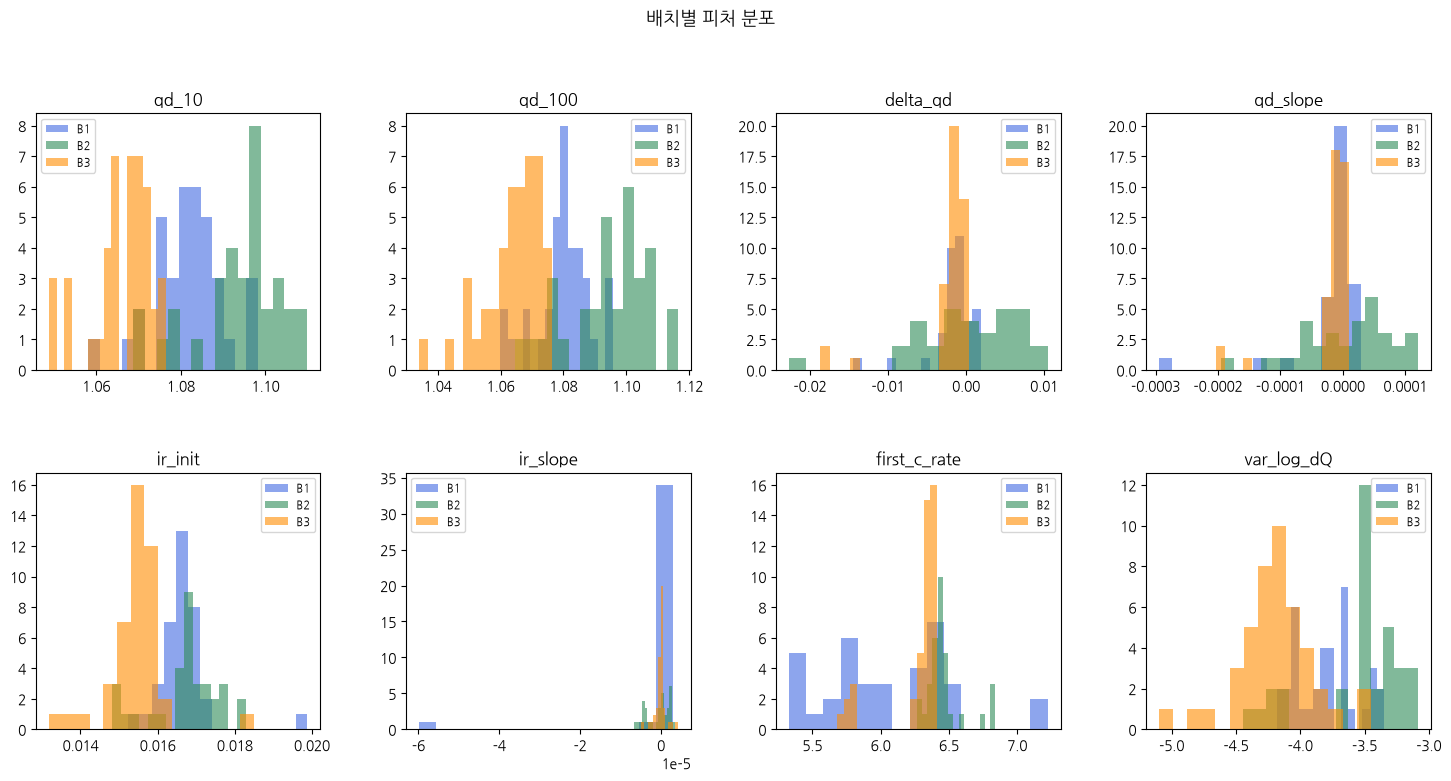

저장: results/feature_distributions.png


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

colors = {'B1': 'royalblue', 'B2': 'seagreen', 'B3': 'darkorange'}

for ax, feat in zip(axes.flat, FEATURES):
    for batch, grp in df.groupby('batch'):
        ax.hist(grp[feat], bins=15, alpha=0.6, color=colors[batch], label=batch)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('배치별 피처 분포', fontsize=13, y=1.01)
plt.savefig(f'{OUT}/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: results/feature_distributions.png')

## 2. 피처-수명 상관관계 (Spearman)

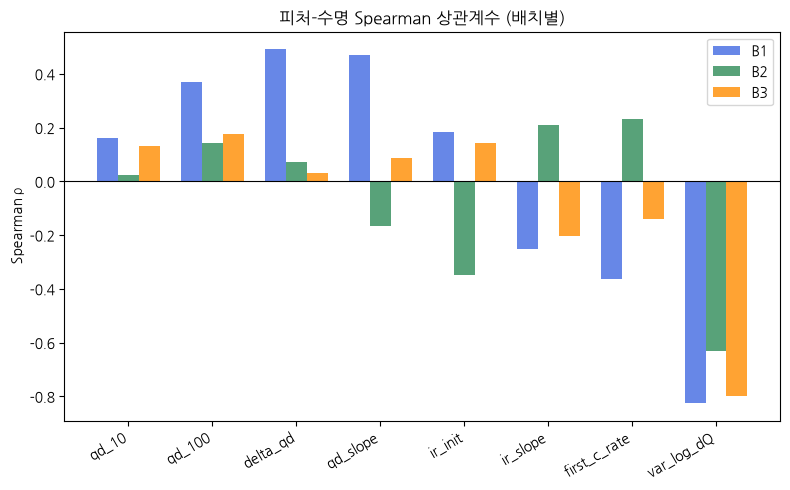

batch            B1     B2     B3
feature                          
qd_10         0.163  0.024  0.130
qd_100        0.370  0.143  0.178
delta_qd      0.491  0.073  0.032
qd_slope      0.468 -0.166  0.088
ir_init       0.182 -0.349  0.142
ir_slope     -0.252  0.211 -0.203
first_c_rate -0.365  0.233 -0.141
var_log_dQ   -0.826 -0.631 -0.797


In [4]:
corr_rows = []
for batch, grp in df.groupby('batch'):
    for feat in FEATURES:
        r, p = spearmanr(grp[feat], grp['cycle_life'])
        corr_rows.append({'batch': batch, 'feature': feat, 'rho': r, 'p': p})

corr_df = pd.DataFrame(corr_rows).pivot(index='feature', columns='batch', values='rho')
corr_df = corr_df.loc[FEATURES]  # FEATURES 순서로 정렬 (알파벳 정렬 방지)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(FEATURES))
w = 0.25
for i, (batch, col) in enumerate(colors.items()):
    ax.bar(x + i*w, corr_df[batch], w, label=batch, color=col, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x + w); ax.set_xticklabels(FEATURES, rotation=30, ha='right')
ax.set_ylabel('Spearman ρ')
ax.set_title('피처-수명 Spearman 상관계수 (배치별)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT}/feature_correlation_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

print(corr_df.round(3))

## 3. 피처 선정 근거 요약

| 피처 | B1 ρ | B2 ρ | B3 ρ | 주요 근거 |
|---|---|---|---|---|
| `var_log_dQ` | −0.826 | −0.631 | −0.797 | **배치 전반 최강 예측력** — Severson 논문 핵심 피처. RF/ElasticNet 모두 중요도 1위 |
| `delta_qd` | +0.491 | +0.073 | +0.032 | B1 두 번째 강한 상관 — 초기 용량 변화량(LFP 활성화 반영) |
| `qd_slope` | +0.468 | −0.166 | +0.088 | 초기 열화 속도 직접 측정 |
| `qd_100` | +0.370 | +0.143 | +0.178 | 100사이클 시점 용량 절대값 |
| `ir_slope` | −0.252 | +0.211 | −0.203 | 저항 증가율 → SEI 성장 반영 |
| `first_c_rate` | −0.365 | +0.233 | −0.141 | 충전 프로토콜 그룹 구분 (RF 중요도 2위: 0.072) |
| `ir_init` | +0.182 | −0.349 | +0.142 | 초기 저항 — 셀 개체차 반영 |
| `qd_10` | +0.163 | +0.024 | +0.130 | 초기 용량 기준값 |

> **핵심 인사이트**: B1에서 `delta_qd`(+0.491)가 `qd_10`(+0.163)보다 훨씬 강한 상관  
> → Cycle 10→100 사이 용량이 증가한 셀(LFP 활성화 범프 발생)이 장수명 경향  
> → `var_log_dQ`는 배치 불문 −0.63~−0.83로 압도적 일관성 (Severson 2019 재현)
